# Logistic Regression with a Neural Network mindset

Here we build a classifier to recongnize, using NN mindset and so also hone our intuition about deep learning.




In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from PIL import Image
from scipy import ndimage
from lr_utils import load_dataset

%matplotlib inline


## Overview :

**Problem statement** : You are given a dataset ("data.h5") containing: - a training set of m_train images labeled as cat (y=1) or non-cat (y=0) - a test set of m_test images labeled as cat or non-cat - each image is of shape (num_px, num_px, 3) where 3 is for the 3 channels (RGB). Thus, each image is square (height = num_px) and (width = num_px).

We build a simple image-recognition algorithm that can correctly classify pictures as cat or non-cat.


Let's get more familiar with the dataset. Load the data by running the following code.

In [2]:
# Loading the data (cat/non-cat)
train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes =  load_dataset()


We added "_orig" at the end of image datasets (train and test) because we are going to preprocess them. After preprocessing, we will end up with train_set_x and test_set_x (the labels train_set_y and test_set_y don't need any preprocessing).

Each line of your train_set_x_orig and test_set_x_orig is an array representing an image. You can visualize an example by running the following code. Feel free also to change the index value and re-run to see other images.

y = [1], it is a 'cat' picture.


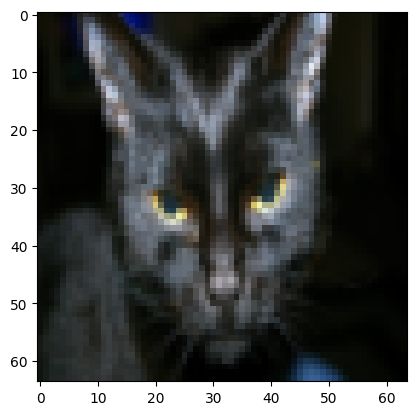

In [3]:
index = 25
plt.imshow(train_set_x_orig[index])
print("y = " + str(train_set_y[:, index]) + ", it is a '" + classes[np.squeeze(train_set_y[:, index])].decode('utf-8') + "' picture.")

Many software bugs in deep learning come from having matrix/vector dimensions that don't fit. If you can keep your matrix/vector dimensions straight you will go a long way toward eliminating many bugs.

**Exercise** : Find the values for: - m_train (number of training examples) - m_test (number of test examples) - num_px (= height = width of a training image) Remember that `train_set_x_orig` is a numpy-array of shape `(m_train, num_px, num_px, 3)`. For instance, you can access `m_train` by writing `train_set_x_orig.shape[0]`.

In [4]:
m_train  = train_set_y.shape[1]
m_test = test_set_y.shape[1]
num_px = train_set_x_orig.shape[1]

print('Number of training examples: m_train = ' + str(m_train))
print("Number of testing examples: m_test = " + str(m_test))
print("Height/Width of each image: num_px = " + str(num_px))
print("train_set_x shape: " + str(train_set_x_orig.shape))
print("train_test_y shape: " + str(train_set_y.shape))
print("test_set_x shape: " + str(test_set_x_orig.shape))
print("test_set_y shape: " + str(test_set_y.shape))

Number of training examples: m_train = 209
Number of testing examples: m_test = 50
Height/Width of each image: num_px = 64
train_set_x shape: (209, 64, 64, 3)
train_test_y shape: (1, 209)
test_set_x shape: (50, 64, 64, 3)
test_set_y shape: (1, 50)


For convenience, you should now reshape images of shape (num_px, num_px, 3) in a numpy-array of shape (num_px * num_px  * 3, 1). After this, our training (and test) dataset is a numpy-array where each column represents a flattened image. There should be m_train (respectively m_test) columns.

A trick when you want to flatten a matrix X of shape (a,b,c,d) to a matrix X_flatten of shape (b*c*d, a) is to use:

X_flatten = X.reshape(X.shape[0], -1).T    # X.T is the transpose of  X.

In [5]:
train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
test_set_x_flattten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T

print("train_set_x_flattten shape " + str(train_set_x_flatten.shape))
print("train_set_y shape: " + str(train_set_y.shape))
print("test_set_x_flatten shape: " + str(test_set_x_flattten.shape))
print("test_set_y_shape: " + str(test_set_y.shape))
print ("sanity check after reshaping: " + str(train_set_x_flatten[0:5,0]))


train_set_x_flattten shape (12288, 209)
train_set_y shape: (1, 209)
test_set_x_flatten shape: (12288, 50)
test_set_y_shape: (1, 50)
sanity check after reshaping: [17 31 56 22 33]


To represent color images, the red, green and blue channels (RGB) must be specified for each pixel, and so the pixel value is actually a vector of three numbers ranging from 0 to 255.
One common preprocessing step in machine learning is to center and standardize your dataset, meaning that you substract the mean of the whole numpy array from each example, and then divide each example by the standard deviation of the whole numpy array. But for picture datasets, it is simpler and more convenient and works almost as well to just divide every row of the dataset by 255 (the maximum value of a pixel channel).

Let's standardize the dataset



In [6]:
train_set_x = train_set_x_flatten / 255.
test_set_x = test_set_x_flattten / 255.

** Note**
**Common steps for pre-processing a new dataset are:**
* Figure out the dimension of the problem (m_train, m_test, nun_px ...)
* Reshape the datasets such that each examples is now a vector of size (num_px * num_px * 3, 1)
* "Standardize" the data

## General Architecture of the learning algorithm.
It's time to design a simple algorithm to distinguish cat images from non-cat images.

We will build a Logistic Regression , using a Neural Network mindset. The following figure explain why **Logistic Regression is actually a very simple Neural Network!**

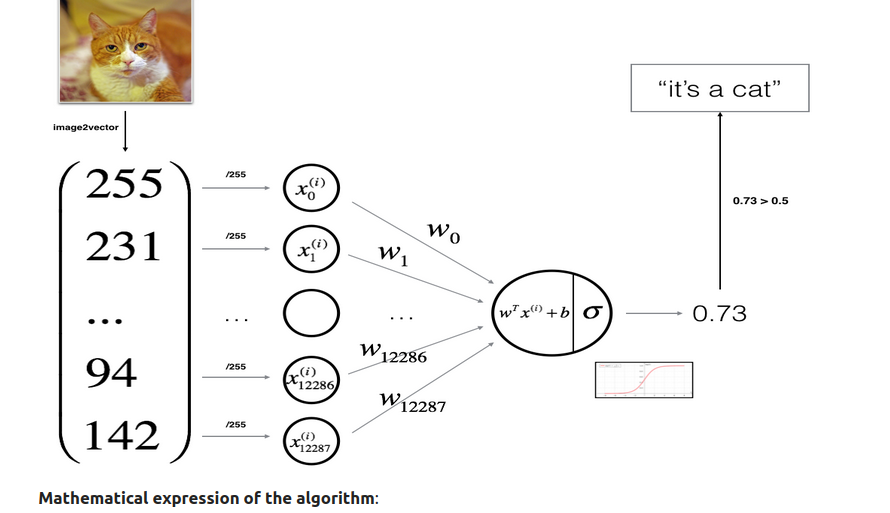



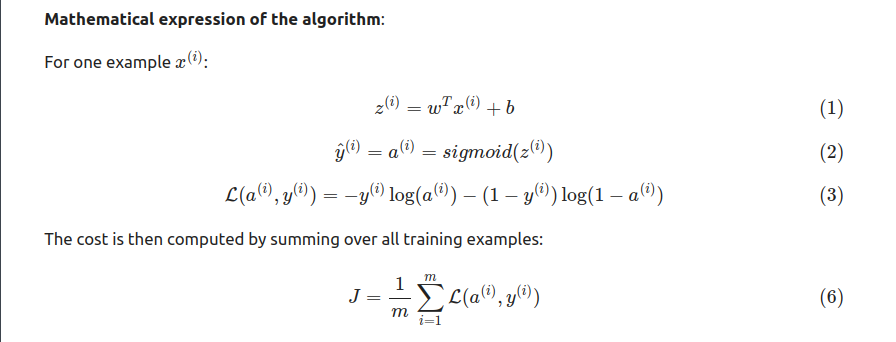

** Key steps** : In this exercise, you will carry out the following steps: - Initialize the parameters of the model - Learn the parameters for the model by minimizing the cost
- Use the learned parameters to make predictions (on the test set) - Analyse the results and conclude


## Building Parts of our Algorithm.

The main steps for building the Neural Network are:

1. Define the model structrue (such as number of input features)
2. Initialize the model's parameters
3. Loop:
  * calculate the current loss (forward pass)
  * Calcualte current gradient (backward propagation)
  * Update the parameters (gradient descent)

We often build the steps 1-3 seperately and integarte them  into one function we call `model()`



### Helper functions.


In [7]:
def sigmoid(z):
  s = 1 / (1 + np.exp(-z))

  return s


In [8]:
print("sigmoid of 0 = " + str(sigmoid(0)))
print("sigmoid of (9.3) = " + str(sigmoid(9.2)))

sigmoid of 0 = 0.5
sigmoid of (9.3) = 0.9998989708060922


## initializing parameters

We initialize a vector of zeors.

In [9]:
def initialize_with_zeros(dim):
  """
  This function creates a vector of zeros of shape (dim, 1) for w and initializes b to 0.

  Argument:
  dim -- size of the w vector we want (or number of parameters in this case)

  Returns:
  w -- initialized vector of shape (dim, 1)
  b -- initialized scalar (corresponds to the bias)
  """

  w = np.zeros(shape=(dim, 1))

  b = 0

  assert(w.shape == (dim, 1))
  assert(isinstance(b, float) or isinstance(b, int))

  return w, b



In [10]:
dim = 2
w, b = initialize_with_zeros(dim)

print("w = " + str(w))
print("b = " + str(b))

w = [[0.]
 [0.]]
b = 0


For image inputs, w will be of shape (num_px x num_px x 3, 1).

## Forward and backward propagation
Now that your parameters are initialized, you can do the "forward" and "backward" propagation steps for learning the parameters.

We implement the funciton `propagate()` that computes the cost function and its gradient.

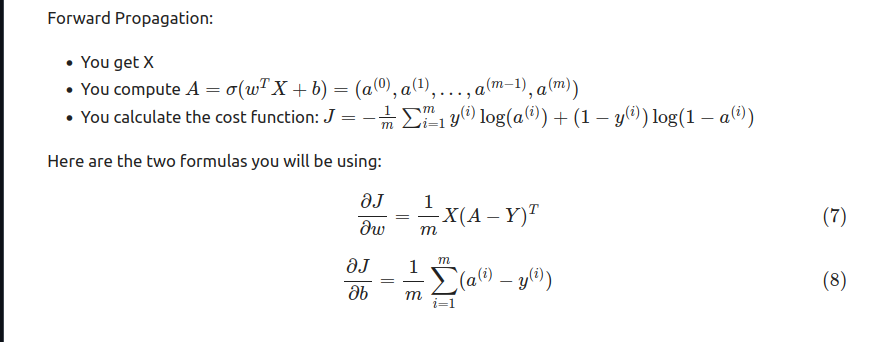

In [18]:
def propagate(w, b, X, Y):
    """
    Implement the cost function and its gradient for the propagation explained above

    Arguments:
    w -- weights, a numpy array of size (num_px * num_px * 3, 1)
    b -- bias, a scalar
    X -- data of size (num_px * num_px * 3, number of examples)
    Y -- true "label" vector (containing 0 if non-cat, 1 if cat) of size (1, number of examples)

    Return:
    cost -- negative log-likelihood cost for logistic regression
    dw -- gradient of the loss with respect to w, thus same shape as w
    db -- gradient of the loss with respect to b, thus same shape as b

    Tips:
    - Write your code step by step for the propagation
    """

    m = X.shape[1]

    # FORWARD PROPAGATION (FROM X TO COST)
    ### START CODE HERE ### (≈ 2 lines of code)
    A = sigmoid(np.dot(w.T, X) + b)  # compute activation
    cost = (- 1 / m) * np.sum(Y * np.log(A) + (1 - Y) * (np.log(1 - A)))  # compute cost
    ### END CODE HERE ###

    # BACKWARD PROPAGATION (TO FIND GRAD)
    ### START CODE HERE ### (≈ 2 lines of code)
    dw = (1 / m) * np.dot(X, (A - Y).T)
    db = (1 / m) * np.sum(A - Y)
    ### END CODE HERE ###

    assert(dw.shape == w.shape)
    assert(db.dtype == float)
    cost = np.squeeze(cost)
    assert(cost.shape == ())
    grads = {"dw": dw,
             "db": db}

    return grads, cost


In [19]:
w, b, X, Y = np.array([[1], [2]]), 2, np.array([[1,2], [3,4]]), np.array([[1, 0]])
grads, cost = propagate(w, b, X, Y)
print("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))
print ("cost = " + str(cost))

dw = [[0.99993216]
 [1.99980262]]
db = 0.49993523062470574
cost = 6.000064773192205


## Optimization
* We have initialized your parameters.
*  We also able to compute a cost function and its gradient.

* Now, we want to update the parameters using gradient descent.

Exercise: Write down the optimization function. The goal is to learn w and b by minimizing the cost function J. For a parameter $$θ$$,  the update rule is $\theta - α d\theta$  , where $α$ is the learning rate.

In [21]:
def optimize(w, b, X, Y, num_iterations, learning_rate, print_cost =False):

  costs = []

  for i in range(num_iterations):
    grads,cost = propagate(w, b, X, Y)

    dw = grads['dw']
    db = grads['db']

    w = w - learning_rate * dw
    b = b - learning_rate * db

    if i % 100 == 0:
      print("Cost after every iteration %i: %f"  % (i, cost))
  params = {"w": w,
            "b": b}
  grads = {"dw": dw,
           "db": db}

  return params, grads, costs


In [22]:
params, grads, costs = optimize(w, b, X, Y, num_iterations= 100, learning_rate = 0.009, print_cost = False)

print("w = " + str(params["w"]))
print ("b = " + str(params["b"]))
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))


Cost after every iteration 0: 6.000065
w = [[0.1124579 ]
 [0.23106775]]
b = 1.5593049248448891
dw = [[0.90158428]
 [1.76250842]]
db = 0.4304620716786828


Exercise: The previous function will output the learned w and b. We are able to use w and b to predict the labels for a dataset X. Implement the predict() function. There is two steps to computing predictions:

1. Calculate the  Y = A = $$σ(w^{T}X + b)$$.
2. convert the entries of a into 0 (if activation <= 0.5) or 1 (if activation > 0.5) stores the predictions in a vector `Y_prediction` . If we wish, we can use an `if/else` statement in a `for` loop (though there is also a way to vectorize this).


In [25]:
def predict(w, b, X):
  """

  Predict whether the label is 0 or 1 using learned logistic regression parameters (w, b)

  Arguments:
  w -- weights, a numpy array of size (num_px * num_px * 3, 1)
  b -- bias, a scalar
  X -- data of size (num_px * num_px * 3, number of examples)

  Returns:
  Y_prediction -- a numpy array (vector) containing all predictions (0/1) for the examples in X
  """
  m = X.shape[1]
  Y_prediction = np.zeros((1, m))
  w = w.reshape(X.shape[0], 1)

  A = sigmoid(np.dot(w.T, X) + b)

  for i in range(A.shape[1]):
    Y_prediction[0, i] = 1 if A[0, 1] > 0.5 else 0
  assert(Y_prediction.shape == (1, m))

  return Y_prediction

In [26]:
print("Prediction = " + str(predict(w, b, X)))

Prediction = [[1. 1.]]


 **What to remember:** You've implemented several functions that: - Initialize (w,b) - Optimize the loss iteratively to learn parameters (w,b): - computing the cost and its gradient - updating the parameters using gradient descent - Use the learned (w,b) to predict the labels for a given set of examples

## Merge all functions into a model
You will now see how the overall model is structured by putting together all the building blocks (functions implemented in the previous parts) together, in the right order.

Now we implement the model function. Using the notation - Y_prection for the prediction on the test data set - Y_prediction_train for the predictions on the train_set  - w, costs , grads for the outputs of optimize().



In [33]:
def model(X_train, Y_train, X_test, Y_test, num_iterations=2000, learning_rate=0.5, print_cost = False):
  """
  Builds the logistic regression model by calling the function you've implemented previously

  Arguments:
  X_train -- training set represented by a numpy array of shape (num_px * num_px * 3, m_train)
  Y_train -- training labels represented by a numpy array (vector) of shape (1, m_train)
  X_test -- test set represented by a numpy array of shape (num_px * num_px * 3, m_test)
  Y_test -- test labels represented by a numpy array (vector) of shape (1, m_test)
  num_iterations -- hyperparameter representing the number of iterations to optimize the parameters
  learning_rate -- hyperparameter representing the learning rate used in the update rule of optimize()
  print_cost -- Set to true to print the cost every 100 iterations

  Returns:
  d -- dictionary containing information about the model.
  """

  w, b = initialize_with_zeros(X_train.shape[0])

  # Optimize
  parameters, grads, costs = optimize(
      w, b, X_train, Y_train,
      num_iterations, learning_rate, print_cost
  )

  # Retrieve learned parameters
  w = parameters["w"]
  b = parameters["b"]

  # Predict
  Y_prediction_test = predict(w, b, X_test)
  Y_prediction_train = predict(w, b, X_train)

  # Accuracy
  print("train accuracy: {} %".format(
      100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100
  ))
  print("test accuracy: {} %".format(
      100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100
  ))

  # Save results
  d = {
      "costs": costs,
      "Y_prediction_test": Y_prediction_test,
      "Y_prediction_train": Y_prediction_train,
      "w": w,
      "b": b,
      "learning_rate": learning_rate,
      "num_iterations": num_iterations
  }

  return d



In [34]:
d = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations = 2000, learning_rate = 0.005, print_cost = True)

Cost after every iteration 0: 0.693147
Cost after every iteration 100: 0.584508
Cost after every iteration 200: 0.466949
Cost after every iteration 300: 0.376007
Cost after every iteration 400: 0.331463
Cost after every iteration 500: 0.303273
Cost after every iteration 600: 0.279880
Cost after every iteration 700: 0.260042
Cost after every iteration 800: 0.242941
Cost after every iteration 900: 0.228004
Cost after every iteration 1000: 0.214820
Cost after every iteration 1100: 0.203078
Cost after every iteration 1200: 0.192544
Cost after every iteration 1300: 0.183033
Cost after every iteration 1400: 0.174399
Cost after every iteration 1500: 0.166521
Cost after every iteration 1600: 0.159305
Cost after every iteration 1700: 0.152667
Cost after every iteration 1800: 0.146542
Cost after every iteration 1900: 0.140872
train accuracy: 65.55023923444976 %
test accuracy: 66.0 %


Woops ! We pissed , the accuracy is way too low. And also,  you see that the model is clearly overfitting the training data. Later in this specialization you will learn how to reduce overfitting, for example by using regularization. Using the code below (and changing the index variable) you can look at predictions on pictures of the test set.



IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

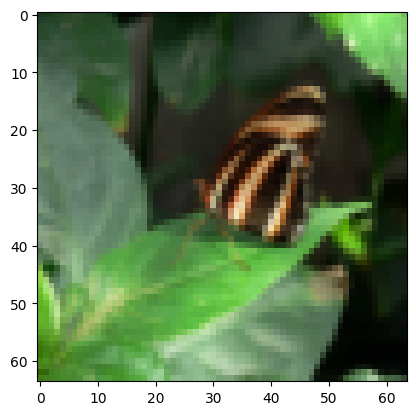

In [35]:
index = 5
plt.imshow(test_set_x[:, index].reshape((num_px, num_px, 3)))
print ("y = " + str(test_set_y[0, index]) + ", you predicted that it is a \"" + classes[d["Y_prediction_test"][0, index]].decode("utf-8") +  "\" picture.")

plotting the cost function and the grads



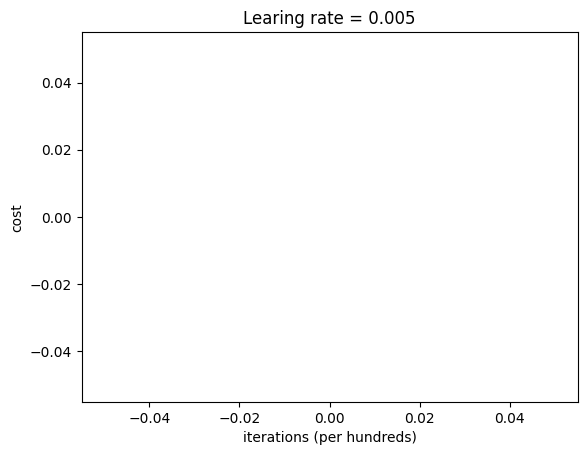

In [32]:
costs = np.squeeze(d['costs'])
plt.plot(costs)
plt.ylabel('cost')
plt.xlabel('iterations (per hundreds)')
plt.title("Learing rate = " + str(d["learning_rate"]))
plt.show()

## Choice of learing rate
Reminder: In order for Gradient Descent to work you must choose the learning rate wisely. The learning rate determines how rapidly we update the parameters. If the learning rate is too large we may "overshoot" the optimal value. Similarly, if it is too small we will need too many iterations to converge to the best values. That's why it is crucial to use a well-tuned learning rate.

Let's compare the learning curve of our model with several choices of learning rates. Run the cell below. This should take about 1 minute. Feel free also to try different values than the three we have initialized the learning_rates variable to contain, and see what happens.

learning rate is :0.01
Cost after every iteration 0: 0.693147
Cost after every iteration 100: 0.823921
Cost after every iteration 200: 0.418944
Cost after every iteration 300: 0.617350
Cost after every iteration 400: 0.522116
Cost after every iteration 500: 0.387709
Cost after every iteration 600: 0.236254
Cost after every iteration 700: 0.154222
Cost after every iteration 800: 0.135328
Cost after every iteration 900: 0.124971
Cost after every iteration 1000: 0.116478
Cost after every iteration 1100: 0.109193
Cost after every iteration 1200: 0.102804
Cost after every iteration 1300: 0.097130
Cost after every iteration 1400: 0.092043
train accuracy: 65.55023923444976 %
test accuracy: 66.0 %

-----------------------------------------------
learning rate is :0.001
Cost after every iteration 0: 0.693147
Cost after every iteration 100: 0.591289
Cost after every iteration 200: 0.555796
Cost after every iteration 300: 0.528977
Cost after every iteration 400: 0.506881
Cost after every iteratio

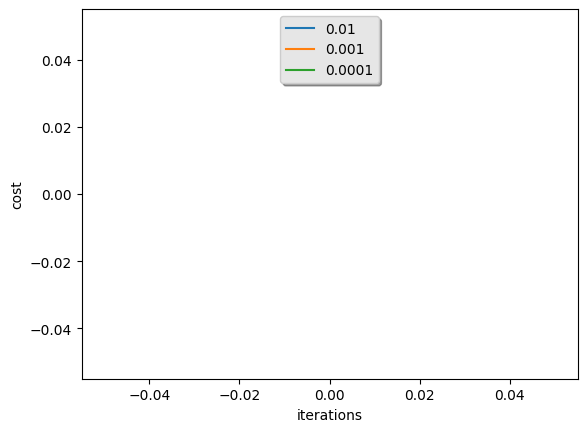

In [37]:
learning_rates = [0.01, 0.001, 0.0001]
models = {}

for i in learning_rates:
  print("learning rate is :" + str(i))
  models[str(i)]  = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations=1500, learning_rate=i, print_cost=False)
  print("\n" + "-----------------------------------------------")

for i in learning_rates:
  plt.plot(np.squeeze(models[str(i)]['costs']), label=str(models[str(i)]['learning_rate']))
plt.ylabel('cost')
plt.xlabel('iterations')

legend = plt.legend(loc='upper center', shadow=True)
frame = legend.get_frame()
frame.set_facecolor('0.90')
plt.show()






Interpretation:

    * Different learning rates give different costs and thus different predictions results.
    * If the learning rate is too large (0.01), the cost may oscillate up and down. It may even diverge (though in this example, using 0.01 still eventually ends up at a good value for the cost).
    * A lower cost doesn't mean a better model. You have to check if there is possibly overfitting. It happens when the training accuracy is a lot higher than the test accuracy.
    * In deep learning, we usually recommend that you:
       * Choose the learning rate that better minimizes the cost function.
      * If your model overfits, use other techniques to reduce overfitting.
